# Vergelijking van de CNN-modellen

In dit notebook worden de resultaten van de verschillende 1D- en 2D-CNN-experimenten met elkaar vergeleken.

Omdat de ECG-dataset ongebalanceerd is, wordt niet alleen naar accuracy gekeken. De recall per klasse en de gemiddelde recall zijn belangrijker, omdat vooral de kleinere klassen goed herkend moeten worden.

De resultaten zijn afkomstig uit de losse notebooks waarin de modellen zijn getraind.

In [171]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [172]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
)

blue_palette = sns.color_palette(
    "Blues",
    n_colors=7,
)[2:]   

# Resultaten inladen

In [173]:
results_file = Path("results/results.csv")

if not results_file.exists():
    raise FileNotFoundError(
        f"Bestand niet gevonden: {results_file.resolve()}"
    )

results = pd.read_csv(results_file)

results

,Experiment,Run,Class Weights,Parallel,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Training_Time_Seconds
0,1D CNN Baseline,1,False,False,0.944901,0.989896,0.446847,0.744138,0.291925,0.856611,25.717649
1,1D CNN Baseline,2,False,False,0.936266,0.990616,0.228007,0.672652,0.209877,0.879751,20.025517
2,1D CNN Baseline,3,False,False,0.911687,0.997569,0.098039,0.349757,0.000000,0.825524,19.932446
3,1D CNN Weighted,1,True,False,0.613761,0.570719,0.739677,0.715964,0.865854,0.939337,20.450566
4,1D CNN Weighted,2,True,False,0.754706,0.735492,0.672630,0.816980,0.875776,0.932626,20.264164
5,1D CNN Weighted,3,True,False,0.787007,0.781555,0.684492,0.757975,0.791411,0.910168,23.581893
6,2D CNN Baseline,1,True,False,0.942982,0.994755,0.223827,0.721187,0.251534,0.877564,18.780584
7,2D CNN Baseline,2,True,False,0.936769,0.994371,0.114545,0.679310,0.265432,0.868454,18.606132
8,2D CNN Baseline,3,True,False,0.938231,0.995582,0.110912,0.706612,0.073171,0.877182,18.910597
9,2D CNN Weighted,1,True,False,0.766310,0.758861,0.679144,0.738472,0.872727,0.895925,18.460296


# Data preprocessing

In [174]:
experiment_names = {
    "1D CNN Baseline": "1D-CNN baseline",
    "1D CNN Weighed": "1D-CNN met class weights",
    "1D CNN Weighted": "1D-CNN met class weights",
    "2D CNN baseline": "2D-CNN baseline",
    "2D CNN Baseline": "2D-CNN baseline",
    "2D CNN Weighed": "2D-CNN met class weights",
    "2D CNN Weighted": "2D-CNN met class weights",
    "2D CNN parallel": "Parallelle 2D-CNN",
    "Parallelle 2D CNN": "Parallelle 2D-CNN",
}

results["Experiment"] = results["Experiment"].replace(
    experiment_names
)

results

,Experiment,Run,Class Weights,Parallel,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Training_Time_Seconds
0,1D-CNN baseline,1,False,False,0.944901,0.989896,0.446847,0.744138,0.291925,0.856611,25.717649
1,1D-CNN baseline,2,False,False,0.936266,0.990616,0.228007,0.672652,0.209877,0.879751,20.025517
2,1D-CNN baseline,3,False,False,0.911687,0.997569,0.098039,0.349757,0.000000,0.825524,19.932446
3,1D-CNN met class weights,1,True,False,0.613761,0.570719,0.739677,0.715964,0.865854,0.939337,20.450566
4,1D-CNN met class weights,2,True,False,0.754706,0.735492,0.672630,0.816980,0.875776,0.932626,20.264164
5,1D-CNN met class weights,3,True,False,0.787007,0.781555,0.684492,0.757975,0.791411,0.910168,23.581893
6,2D-CNN baseline,1,True,False,0.942982,0.994755,0.223827,0.721187,0.251534,0.877564,18.780584
7,2D-CNN baseline,2,True,False,0.936769,0.994371,0.114545,0.679310,0.265432,0.868454,18.606132
8,2D-CNN baseline,3,True,False,0.938231,0.995582,0.110912,0.706612,0.073171,0.877182,18.910597
9,2D-CNN met class weights,1,True,False,0.766310,0.758861,0.679144,0.738472,0.872727,0.895925,18.460296


In [175]:
experiment_order = [
    "1D-CNN baseline",
    "2D-CNN baseline",
    "1D-CNN met class weights",
    "2D-CNN met class weights",
    "Parallelle 2D-CNN",
]

results["Experiment"] = pd.Categorical(
    results["Experiment"],
    categories=experiment_order,
    ordered=True,
)

results = results.sort_values(
    ["Experiment", "Run"]
).reset_index(drop=True)

results

,Experiment,Run,Class Weights,Parallel,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Training_Time_Seconds
0,1D-CNN baseline,1,False,False,0.944901,0.989896,0.446847,0.744138,0.291925,0.856611,25.717649
1,1D-CNN baseline,2,False,False,0.936266,0.990616,0.228007,0.672652,0.209877,0.879751,20.025517
2,1D-CNN baseline,3,False,False,0.911687,0.997569,0.098039,0.349757,0.000000,0.825524,19.932446
3,2D-CNN baseline,1,True,False,0.942982,0.994755,0.223827,0.721187,0.251534,0.877564,18.780584
4,2D-CNN baseline,2,True,False,0.936769,0.994371,0.114545,0.679310,0.265432,0.868454,18.606132
5,2D-CNN baseline,3,True,False,0.938231,0.995582,0.110912,0.706612,0.073171,0.877182,18.910597
6,1D-CNN met class weights,1,True,False,0.613761,0.570719,0.739677,0.715964,0.865854,0.939337,20.450566
7,1D-CNN met class weights,2,True,False,0.754706,0.735492,0.672630,0.816980,0.875776,0.932626,20.264164
8,1D-CNN met class weights,3,True,False,0.787007,0.781555,0.684492,0.757975,0.791411,0.910168,23.581893
9,2D-CNN met class weights,1,True,False,0.766310,0.758861,0.679144,0.738472,0.872727,0.895925,18.460296


# extra meetwaarden berekenen

In [176]:
recall_columns = [
    "Recall_N",
    "Recall_S",
    "Recall_V",
    "Recall_F",
    "Recall_Q",
]

# Gemiddelde van de 5 klasse
results["Macro_Recall"] = results[
    recall_columns
].mean(axis=1)

# Gemiddelde van de 4 afwijkende klassen
results["Recall_Afwijkende_Klassen"] = results[
    [
        "Recall_S",
        "Recall_V",
        "Recall_F",
        "Recall_Q",
    ]
].mean(axis=1)

results[
    [
        "Experiment",
        "Run",
        "Accuracy",
        "Macro_Recall",
        "Recall_Afwijkende_Klassen",
    ]
].round(3)

,Experiment,Run,Accuracy,Macro_Recall,Recall_Afwijkende_Klassen
0,1D-CNN baseline,1,0.945,0.666,0.585
1,1D-CNN baseline,2,0.936,0.596,0.498
2,1D-CNN baseline,3,0.912,0.454,0.318
3,2D-CNN baseline,1,0.943,0.614,0.519
4,2D-CNN baseline,2,0.937,0.584,0.482
5,2D-CNN baseline,3,0.938,0.553,0.442
6,1D-CNN met class weights,1,0.614,0.766,0.815
7,1D-CNN met class weights,2,0.755,0.807,0.825
8,1D-CNN met class weights,3,0.787,0.785,0.786
9,2D-CNN met class weights,1,0.766,0.789,0.797


# Gemiddelde over meerdere runs berekenen

In [177]:
metric_columns = [
    "Accuracy",
    "Recall_N",
    "Recall_S",
    "Recall_V",
    "Recall_F",
    "Recall_Q",
    "Macro_Recall",
    "Recall_Afwijkende_Klassen",
]

#   Gemiddelde van de resultaten per experiment
mean_results = (
    results
    .groupby(
        "Experiment",
        observed=True,
    )[metric_columns]
    .mean()
    .reset_index()
)

# standaarddeviatie van de resultaten per experiment
std_results = (
    results
    .groupby(
        "Experiment",
        observed=True,
    )[metric_columns]
    .std()
    .fillna(0)
    .reset_index()
)

mean_results.round(3)


,Experiment,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Macro_Recall,Recall_Afwijkende_Klassen
0,1D-CNN baseline,0.931,0.993,0.258,0.589,0.167,0.854,0.572,0.467
1,2D-CNN baseline,0.939,0.995,0.150,0.702,0.197,0.874,0.584,0.481
2,1D-CNN met class weights,0.718,0.696,0.699,0.764,0.844,0.927,0.786,0.809
3,2D-CNN met class weights,0.787,0.783,0.663,0.767,0.845,0.896,0.791,0.793
4,Parallelle 2D-CNN,0.862,0.865,0.698,0.841,0.784,0.921,0.822,0.811


In [178]:
std_results.round(3)

,Experiment,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Macro_Recall,Recall_Afwijkende_Klassen
0,1D-CNN baseline,0.017,0.004,0.176,0.210,0.151,0.027,0.108,0.136
1,2D-CNN baseline,0.003,0.001,0.064,0.021,0.107,0.005,0.031,0.038
2,1D-CNN met class weights,0.092,0.111,0.036,0.051,0.046,0.015,0.020,0.020
3,2D-CNN met class weights,0.022,0.023,0.016,0.057,0.042,0.001,0.004,0.004
4,Parallelle 2D-CNN,0.043,0.055,0.045,0.021,0.063,0.026,0.010,0.024


# Complete vergelijkingstabel

In [179]:
comparison_table = mean_results[
    [
        "Experiment",
        "Accuracy",
        "Recall_N",
        "Recall_S",
        "Recall_V",
        "Recall_F",
        "Recall_Q",
        "Macro_Recall",
        "Recall_Afwijkende_Klassen",
    ]
].copy()

comparison_table = comparison_table.sort_values(
    "Macro_Recall",
    ascending=False,
)

comparison_table.round(3)

,Experiment,Accuracy,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q,Macro_Recall,Recall_Afwijkende_Klassen
4,Parallelle 2D-CNN,0.862,0.865,0.698,0.841,0.784,0.921,0.822,0.811
3,2D-CNN met class weights,0.787,0.783,0.663,0.767,0.845,0.896,0.791,0.793
2,1D-CNN met class weights,0.718,0.696,0.699,0.764,0.844,0.927,0.786,0.809
1,2D-CNN baseline,0.939,0.995,0.150,0.702,0.197,0.874,0.584,0.481
0,1D-CNN baseline,0.931,0.993,0.258,0.589,0.167,0.854,0.572,0.467


In [180]:
Path("figures").mkdir(
    parents=True,
    exist_ok=True,
)

Path("tables").mkdir(
    parents=True,
    exist_ok=True,
)

comparison_table.round(4).to_csv(
    "tables/modelvergelijking.csv",
    index=False,
)

# Recall per klasse van alle modellen

In [181]:
experiment_order = [
    "1D-CNN baseline",
    "2D-CNN baseline",
    "1D-CNN met class weights",
    "2D-CNN met class weights",
    "Parallelle 2D-CNN",
]

# Long format voor recall values
recall_long = mean_results.melt(
    id_vars="Experiment",
    value_vars=recall_columns,
    var_name="Klasse",
    value_name="Recall",
)

# Hernoemen klassekolom
recall_long["Klasse"] = (
    recall_long["Klasse"]
    .str.replace("Recall_", "", regex=False)
)

recall_long["Experiment"] = pd.Categorical(
    recall_long["Experiment"],
    categories=experiment_order,
    ordered=True,
)

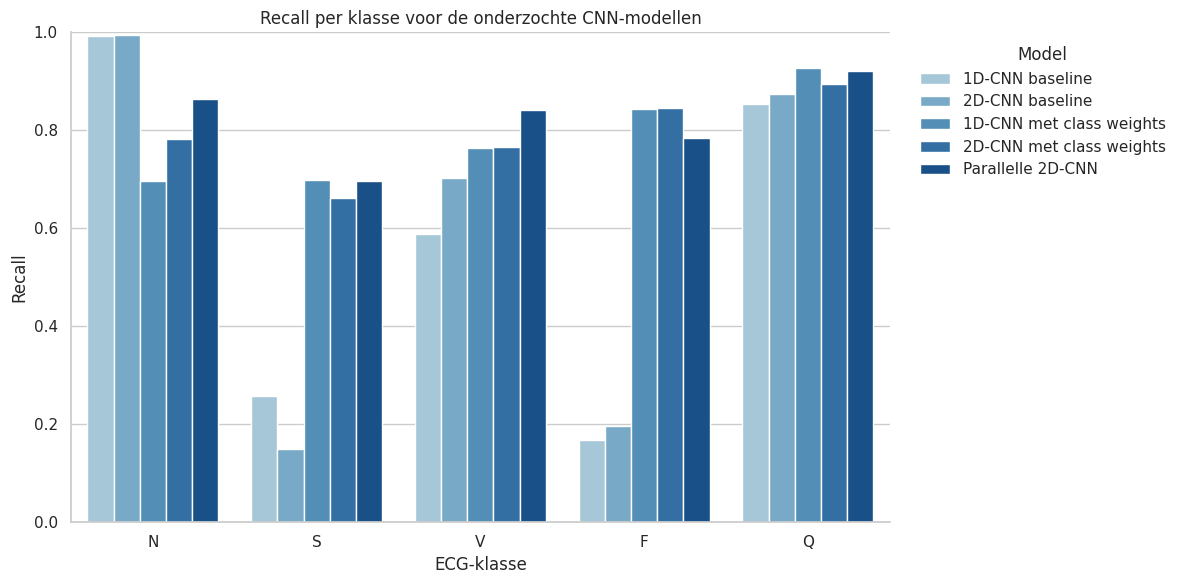

In [182]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=recall_long,
    x="Klasse",
    y="Recall",
    hue="Experiment",
    palette=blue_palette,
)

ax.set_ylim(0, 1)
ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Recall")
ax.set_title(
    "Recall per klasse voor de onderzochte CNN-modellen"
)

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/recall_alle_modellen.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

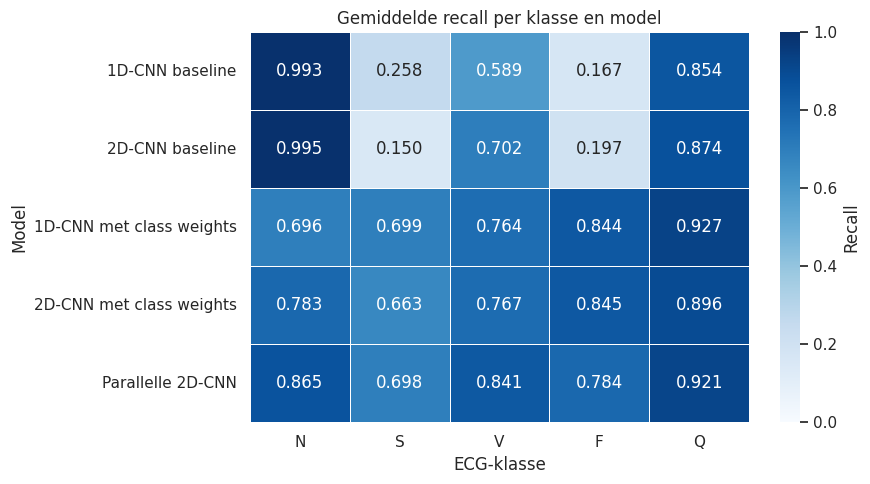

In [183]:
heatmap_data = mean_results.set_index(
    "Experiment"
)[recall_columns].copy()

heatmap_data.columns = [
    "N",
    "S",
    "V",
    "F",
    "Q",
]

plt.figure(figsize=(9, 5))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1,
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={
        "label": "Recall",
    },
)

ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Model")
ax.set_title(
    "Gemiddelde recall per klasse en model"
)

plt.tight_layout()

plt.savefig(
    "figures/heatmap_modelvergelijking.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Baselines vergelijken 

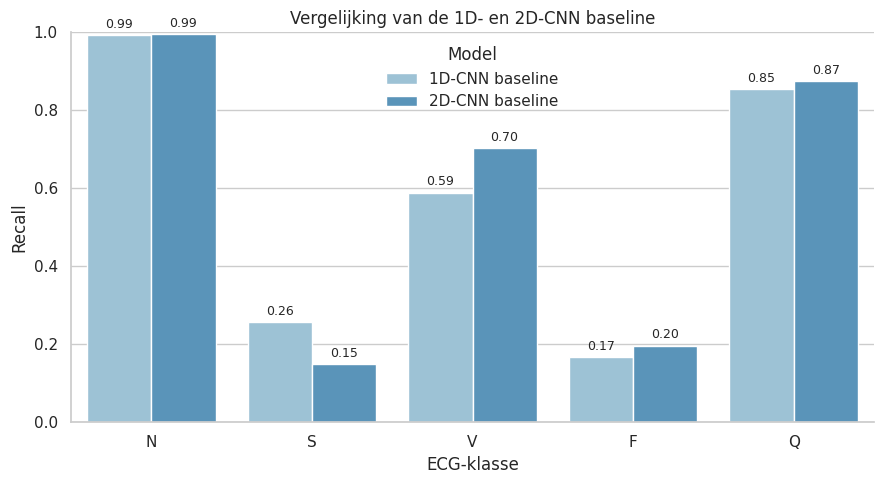

In [184]:
baseline_models = mean_results[
    mean_results["Experiment"].isin(
        [
            "1D-CNN baseline",
            "2D-CNN baseline",
        ]
    )
].copy()

baseline_models["Experiment"] = (
    baseline_models["Experiment"]
    .cat.remove_unused_categories()
)

baseline_long = baseline_models.melt(
    id_vars="Experiment",
    value_vars=recall_columns,
    var_name="Klasse",
    value_name="Recall",
)

baseline_long["Klasse"] = (
    baseline_long["Klasse"]
    .str.replace("Recall_", "", regex=False)
)

plt.close("all")
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=baseline_long,
    x="Klasse",
    y="Recall",
    hue="Experiment",
    palette=sns.color_palette("Blues", n_colors=4)[1:3],
)

# Zet de waarden boven de balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9,
    )

ax.set_ylim(0, 1)
ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Recall")
ax.set_title(
    "Vergelijking van de 1D- en 2D-CNN baseline"
)

ax.legend(
    title="Model",
    frameon=False,
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/baseline_1d_vs_2d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Effect van class weights vergelijken

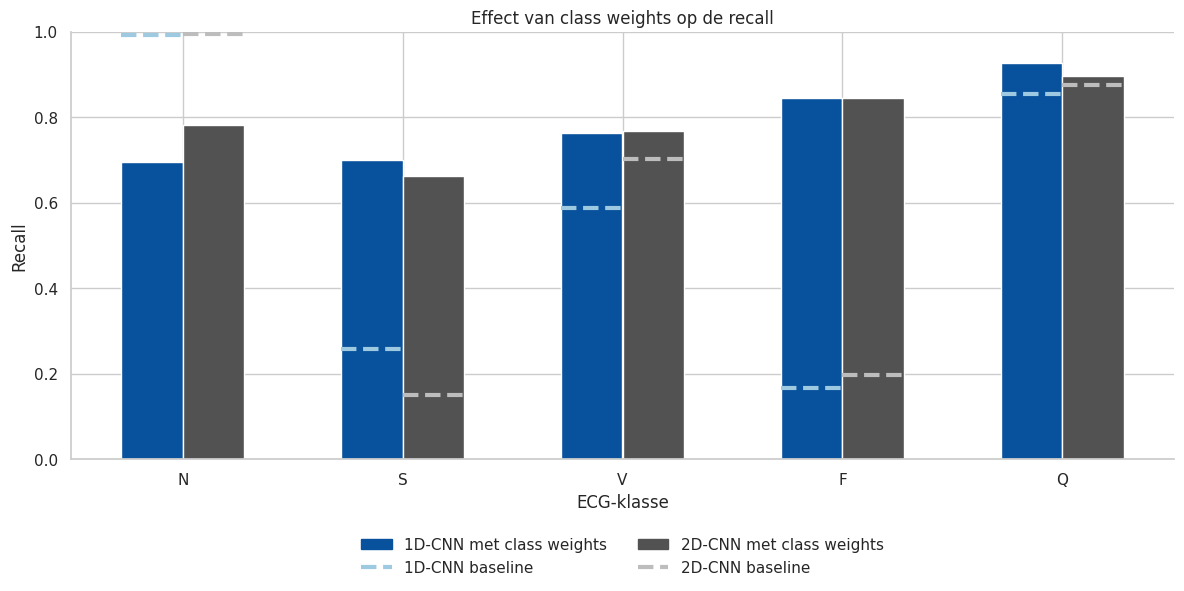

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

classes = ["N", "S", "V", "F", "Q"]

baseline_1d = weight_models.loc[
    weight_models["Experiment"] == "1D-CNN baseline",
    recall_columns,
].values.flatten()

weighted_1d = weight_models.loc[
    weight_models["Experiment"] == "1D-CNN met class weights",
    recall_columns,
].values.flatten()

baseline_2d = weight_models.loc[
    weight_models["Experiment"] == "2D-CNN baseline",
    recall_columns,
].values.flatten()

weighted_2d = weight_models.loc[
    weight_models["Experiment"] == "2D-CNN met class weights",
    recall_columns,
].values.flatten()

x = np.arange(len(classes))
width = 0.28

fig, ax = plt.subplots(figsize=(12,6))

# Balken (gewogen modellen)
ax.bar(
    x - width/2,
    weighted_1d,
    width,
    color="#08519c",
    label="1D-CNN met class weights",
)

ax.bar(
    x + width/2,
    weighted_2d,
    width,
    color="#525252",
    label="2D-CNN met class weights",
)

# Baseline als referentielijnen
for i in range(len(classes)):

    # 1D baseline
    ax.hlines(
        baseline_1d[i],
        x[i]-width,
        x[i],
        colors="#9ecae1",
        linewidth=3,
        linestyles="--",
    )

    # 2D baseline
    ax.hlines(
        baseline_2d[i],
        x[i],
        x[i]+width,
        colors="#bdbdbd",
        linewidth=3,
        linestyles="--",
    )

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.set_ylim(0,1)

ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Recall")
ax.set_title("Effect van class weights op de recall")

from matplotlib.lines import Line2D

legend = [
    plt.Rectangle((0,0),1,1,color="#08519c"),
    Line2D([0],[0],color="#9ecae1",lw=3,ls="--"),
    plt.Rectangle((0,0),1,1,color="#525252"),
    Line2D([0],[0],color="#bdbdbd",lw=3,ls="--"),
]

labels = [
    "1D-CNN met class weights",
    "1D-CNN baseline",
    "2D-CNN met class weights",
    "2D-CNN baseline",
]

ax.legend(
    legend,
    labels,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)

sns.despine()

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.savefig(
    "figures/effect_class_weights.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

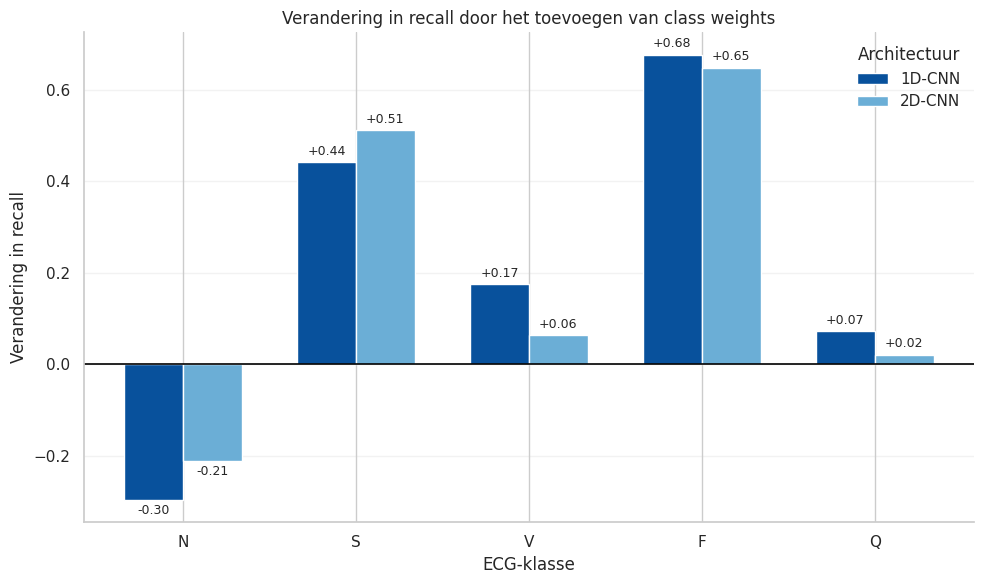

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

classes = ["N", "S", "V", "F", "Q"]

# Resultaten ophalen
baseline_1d = mean_results.loc[
    mean_results["Experiment"] == "1D-CNN baseline",
    recall_columns,
].iloc[0].to_numpy(dtype=float)

weighted_1d = mean_results.loc[
    mean_results["Experiment"] == "1D-CNN met class weights",
    recall_columns,
].iloc[0].to_numpy(dtype=float)

baseline_2d = mean_results.loc[
    mean_results["Experiment"] == "2D-CNN baseline",
    recall_columns,
].iloc[0].to_numpy(dtype=float)

weighted_2d = mean_results.loc[
    mean_results["Experiment"] == "2D-CNN met class weights",
    recall_columns,
].iloc[0].to_numpy(dtype=float)

# Verschil berekenen: weighted - baseline
difference_1d = weighted_1d - baseline_1d
difference_2d = weighted_2d - baseline_2d

x = np.arange(len(classes))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

bars_1d = ax.bar(
    x - width / 2,
    difference_1d,
    width,
    label="1D-CNN",
    color="#08519c",
)

bars_2d = ax.bar(
    x + width / 2,
    difference_2d,
    width,
    label="2D-CNN",
    color="#6baed6",
)

# Nul als duidelijke scheidingslijn
ax.axhline(
    y=0,
    linewidth=1.2,
    color="black",
)

# Waarden boven of onder de balken
ax.bar_label(
    bars_1d,
    fmt="%+.2f",
    padding=3,
    fontsize=9,
)

ax.bar_label(
    bars_2d,
    fmt="%+.2f",
    padding=3,
    fontsize=9,
)

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Verandering in recall")
ax.set_title(
    "Verandering in recall door het toevoegen van class weights"
)

ax.legend(
    title="Architectuur",
    frameon=False,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/verschil_baseline_class_weights.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [187]:
weighted_models = mean_results[
    mean_results["Experiment"].isin(
        [
            "1D-CNN met class weights",
            "2D-CNN met class weights",
        ]
    )
].copy()

weighted_models[
    [
        "Experiment",
        "Accuracy",
        "Macro_Recall",
        "Recall_Afwijkende_Klassen",
        "Recall_N",
        "Recall_S",
        "Recall_V",
        "Recall_F",
        "Recall_Q",
    ]
].round(3)



,Experiment,Accuracy,Macro_Recall,Recall_Afwijkende_Klassen,Recall_N,Recall_S,Recall_V,Recall_F,Recall_Q
2,1D-CNN met class weights,0.718,0.786,0.809,0.696,0.699,0.764,0.844,0.927
3,2D-CNN met class weights,0.787,0.791,0.793,0.783,0.663,0.767,0.845,0.896


In [188]:
weighted_1d = weighted_models[
    weighted_models["Experiment"]
    == "1D-CNN met class weights"
].iloc[0]

weighted_2d = weighted_models[
    weighted_models["Experiment"]
    == "2D-CNN met class weights"
].iloc[0]

comparison = pd.DataFrame({
    "Meetwaarde": [
        "Accuracy",
        "Macro-recall",
        "Recall afwijkende klassen",
        "Recall N",
        "Recall S",
        "Recall V",
        "Recall F",
        "Recall Q",
    ],
    "1D-CNN weighted": [
        weighted_1d["Accuracy"],
        weighted_1d["Macro_Recall"],
        weighted_1d["Recall_Afwijkende_Klassen"],
        weighted_1d["Recall_N"],
        weighted_1d["Recall_S"],
        weighted_1d["Recall_V"],
        weighted_1d["Recall_F"],
        weighted_1d["Recall_Q"],
    ],
    "2D-CNN weighted": [
        weighted_2d["Accuracy"],
        weighted_2d["Macro_Recall"],
        weighted_2d["Recall_Afwijkende_Klassen"],
        weighted_2d["Recall_N"],
        weighted_2d["Recall_S"],
        weighted_2d["Recall_V"],
        weighted_2d["Recall_F"],
        weighted_2d["Recall_Q"],
    ],
})

comparison["Verschil 2D - 1D"] = (
    comparison["2D-CNN weighted"]
    - comparison["1D-CNN weighted"]
)

comparison.round(3)

,Meetwaarde,1D-CNN weighted,2D-CNN weighted,Verschil 2D - 1D
0,Accuracy,0.718,0.787,0.069
1,Macro-recall,0.786,0.791,0.005
2,Recall afwijkende klassen,0.809,0.793,-0.016
3,Recall N,0.696,0.783,0.087
4,Recall S,0.699,0.663,-0.036
5,Recall V,0.764,0.767,0.003
6,Recall F,0.844,0.845,0.001
7,Recall Q,0.927,0.896,-0.032


In [189]:
best_weighted_macro = weighted_models.loc[
    weighted_models["Macro_Recall"].idxmax()
]

best_weighted_abnormal = weighted_models.loc[
    weighted_models[
        "Recall_Afwijkende_Klassen"
    ].idxmax()
]

print(
    "Beste weighted model op macro-recall:",
    best_weighted_macro["Experiment"],
)

print(
    "Beste weighted model op afwijkende klassen:",
    best_weighted_abnormal["Experiment"],
)

Beste weighted model op macro-recall: 2D-CNN met class weights
Beste weighted model op afwijkende klassen: 1D-CNN met class weights


# ontwikkeling 2D CNN vergelijken

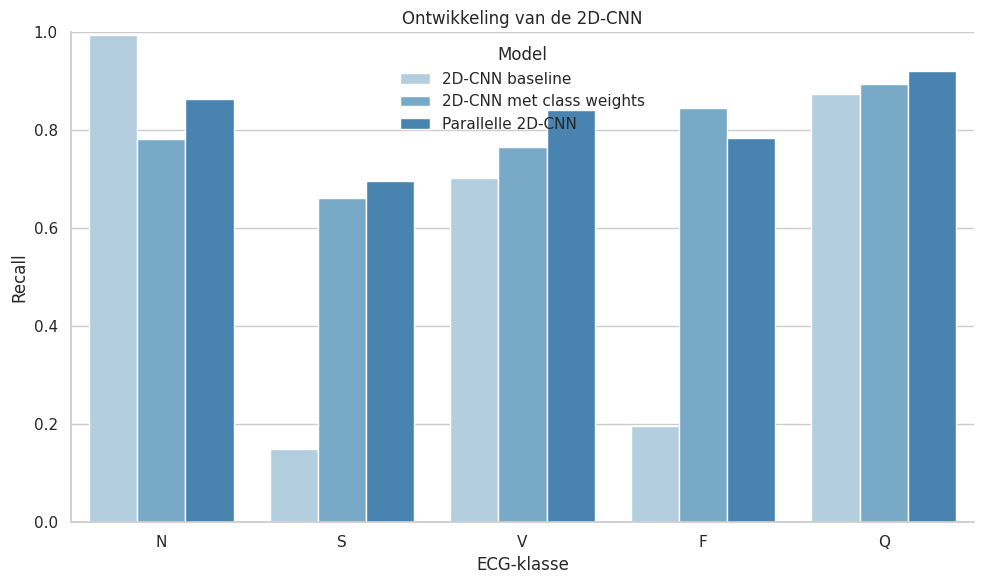

In [190]:
models_2d = mean_results[
    mean_results["Experiment"].isin(
        [
            "2D-CNN baseline",
            "2D-CNN met class weights",
            "Parallelle 2D-CNN",
        ]
    )
].copy()

models_2d["Experiment"] = (
    models_2d["Experiment"]
    .cat.remove_unused_categories()
)

models_2d_long = models_2d.melt(
    id_vars="Experiment",
    value_vars=recall_columns,
    var_name="Klasse",
    value_name="Recall",
)

models_2d_long["Klasse"] = (
    models_2d_long["Klasse"]
    .str.replace("Recall_", "", regex=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=models_2d_long,
    x="Klasse",
    y="Recall",
    hue="Experiment",
    palette=sns.color_palette("Blues", n_colors=5)[1:4],
)

ax.set_ylim(0, 1)
ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Recall")
ax.set_title(
    "Ontwikkeling van de 2D-CNN"
)

ax.legend(
    title="Model",
    frameon=False,
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/ontwikkeling_2d_cnn.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Gewogen 2D CNN tegenover paralelle 2D CNN

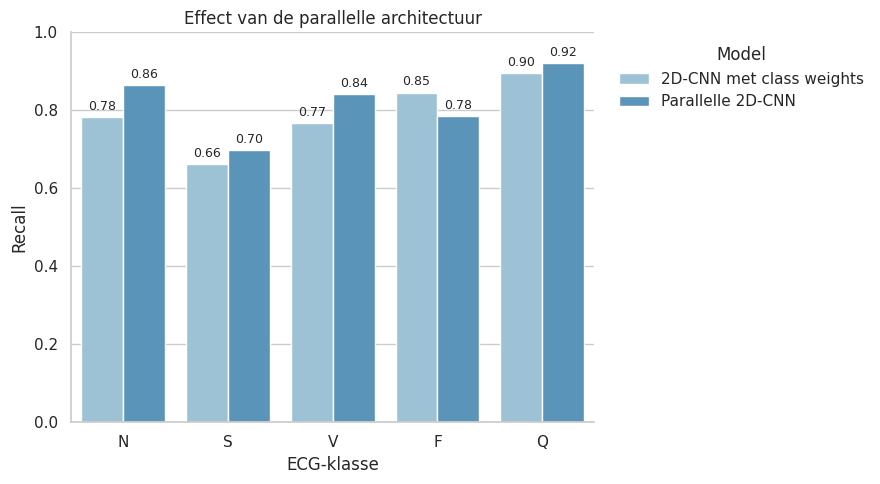

In [191]:
parallel_comparison = mean_results[
    mean_results["Experiment"].isin(
        [
            "2D-CNN met class weights",
            "Parallelle 2D-CNN",
        ]
    )
].copy()

parallel_comparison["Experiment"] = (
    parallel_comparison["Experiment"]
    .cat.remove_unused_categories()
)

parallel_long = parallel_comparison.melt(
    id_vars="Experiment",
    value_vars=recall_columns,
    var_name="Klasse",
    value_name="Recall",
)

parallel_long["Klasse"] = (
    parallel_long["Klasse"]
    .str.replace("Recall_", "", regex=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=parallel_long,
    x="Klasse",
    y="Recall",
    hue="Experiment",
    palette=sns.color_palette("Blues", n_colors=4)[1:3],
)

# Zet de recall boven iedere balk
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9,
    )

ax.set_ylim(0, 1)
ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Recall")
ax.set_title(
    "Effect van de parallelle architectuur"
)

ax.legend(
    title="Model",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/effect_parallelle_2d_cnn.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Verschil tussen gewogen en paralel CNN

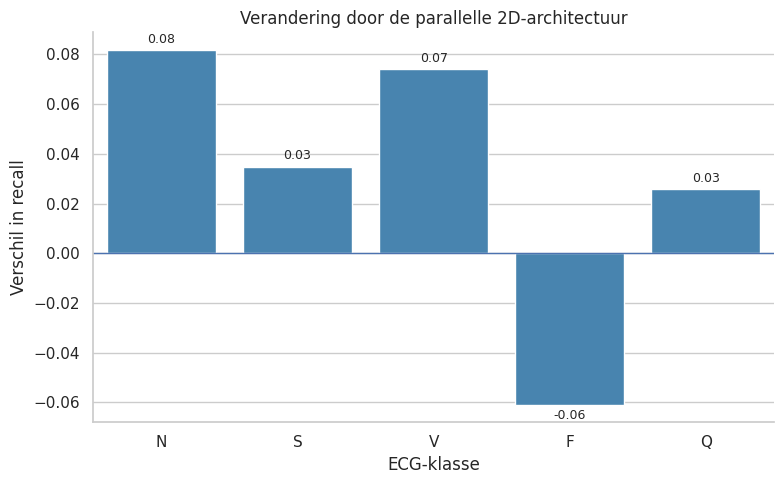

In [192]:
weighted_2d = mean_results[
    mean_results["Experiment"]
    == "2D-CNN met class weights"
].iloc[0]

parallel_2d = mean_results[
    mean_results["Experiment"]
    == "Parallelle 2D-CNN"
].iloc[0]

parallel_difference = pd.DataFrame({
    "Klasse": ["N", "S", "V", "F", "Q"],
    "Verschil": [
        parallel_2d["Recall_N"] - weighted_2d["Recall_N"],
        parallel_2d["Recall_S"] - weighted_2d["Recall_S"],
        parallel_2d["Recall_V"] - weighted_2d["Recall_V"],
        parallel_2d["Recall_F"] - weighted_2d["Recall_F"],
        parallel_2d["Recall_Q"] - weighted_2d["Recall_Q"],
    ],
})

parallel_difference.round(3)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=parallel_difference,
    x="Klasse",
    y="Verschil",
    color=sns.color_palette("Blues", n_colors=5)[3],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xlabel("ECG-klasse")
ax.set_ylabel("Verschil in recall")
ax.set_title(
    "Verandering door de parallelle 2D-architectuur"
)

# Zet de recall boven iedere balk
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "figures/verschil_parallelle_architectuur.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Beste model bepalen

In [193]:
best_macro_model = mean_results.loc[
    mean_results["Macro_Recall"].idxmax()
]

print("Beste model op basis van macro-recall:")
print(best_macro_model["Experiment"])

print(
    f"Macro-recall: "
    f"{best_macro_model['Macro_Recall']:.3f}"
)

best_abnormal_model = mean_results.loc[
    mean_results[
        "Recall_Afwijkende_Klassen"
    ].idxmax()
]

print("Beste model voor de afwijkende klassen:")
print(best_abnormal_model["Experiment"])

print(
    "Gemiddelde recall afwijkende klassen: "
    f"{best_abnormal_model['Recall_Afwijkende_Klassen']:.3f}"
)

Beste model op basis van macro-recall:
Parallelle 2D-CNN
Macro-recall: 0.822
Beste model voor de afwijkende klassen:
Parallelle 2D-CNN
Gemiddelde recall afwijkende klassen: 0.811


# Beste klasse per model en beste model per klasse  

In [194]:
best_per_class = {}

for recall_column in recall_columns:
    class_name = recall_column.replace("Recall_", "")

    best_row = mean_results.loc[
        mean_results[recall_column].idxmax()
    ]

    best_per_class[class_name] = {
        "Model": best_row["Experiment"],
        "Recall": best_row[recall_column],
    }

best_per_class_df = (
    pd.DataFrame(best_per_class)
    .T
    .reset_index()
    .rename(columns={"index": "Klasse"})
)

best_per_class_df.round(3)

,Klasse,Model,Recall
0,N,2D-CNN baseline,0.994903
1,S,1D-CNN met class weights,0.698933
2,V,Parallelle 2D-CNN,0.840903
3,F,2D-CNN met class weights,0.845376
4,Q,1D-CNN met class weights,0.927377


# Samenvatting

In [195]:
best_per_class = []

for recall_column in recall_columns:
    class_name = recall_column.replace("Recall_", "")

    best_row = results.loc[
        results[recall_column].idxmax()
    ]

    best_per_class.append({
        "Klasse": class_name,
        "Beste model": best_row["Experiment"],
        "Type": "1D" if "1D" in str(best_row["Experiment"]) else "2D",
        "Class weights": best_row["Class Weights"],
        "Parallel": best_row["Parallel"],
        "Recall": round(best_row[recall_column], 3),
    })

best_per_class_df = pd.DataFrame(best_per_class)

best_per_class_df

,Klasse,Beste model,Type,Class weights,Parallel,Recall
0,N,1D-CNN baseline,1D,False,False,0.998
1,S,Parallelle 2D-CNN,2D,True,True,0.746
2,V,Parallelle 2D-CNN,2D,True,True,0.863
3,F,1D-CNN met class weights,1D,True,False,0.876
4,Q,Parallelle 2D-CNN,2D,True,True,0.950


# Trainingstijd vergelijken

/tmp/ipykernel_31900/1893721148.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Experiment")["Training_Time_Seconds"]


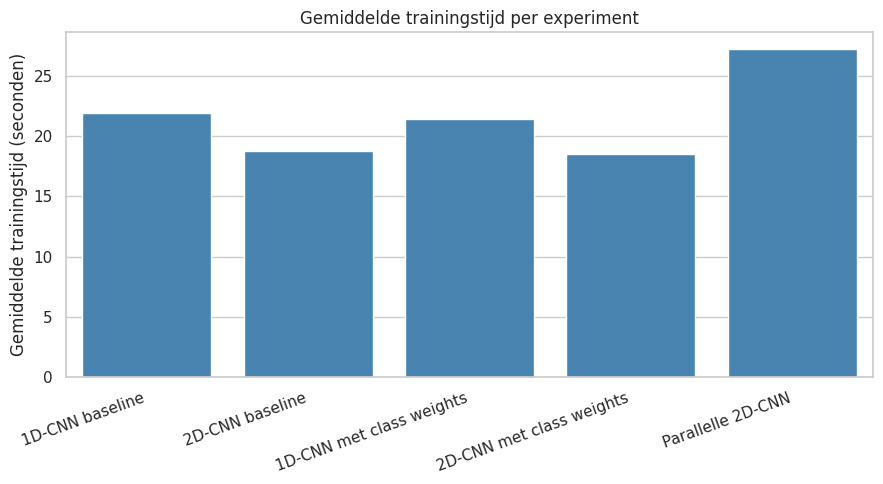

In [196]:
time_summary = (
    results
    .groupby("Experiment")["Training_Time_Seconds"]
    .agg(["mean", "std"])
    .reset_index()
)

time_summary["mean_minutes"] = (
    time_summary["mean"]
)

time_summary.round(2)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=time_summary,
    x="Experiment",
    y="mean_minutes",
    color=sns.color_palette("Blues", 5)[3],
)

plt.xlabel("")
plt.ylabel("Gemiddelde trainingstijd (seconden)")
plt.title("Gemiddelde trainingstijd per experiment")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()